<a href="https://colab.research.google.com/github/RafaelMTu/felicidade-idade-pais/blob/main/PUCSP_CS_AI_10_AI_ML_Happines_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste LAB explorar os modelos de Regressão Linear e Regressão Logística com Scikit-Learn em Python, sobre os dados de "Happines por idade e país"**

- Regressão Linear: <br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- Regressão Logistica: <br>
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# LAB: Felicidade por Idade e por País

> ### Informações da atividade
>
> - **Formato:** projeto em **dupla** pairing - [pair programming](https://en.wikipedia.org/wiki/Pair_programming) (2 estudantes). Os dois participam de todas as etapas e os dois precisam ter commits no repositório.
> - **Prazo:** até o **final do dia** da aula LAB. A atividade **pode ser feita durante a aula de laboratório**.
> - **Publicação:** publiquem o projeto no **GitHub**, como item do **portfólio** da dupla, e enviem o **link do repositório** na **atividade do MS Teams**.

**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | *(preencha)* | *(preencha)* |
| Integrante 2 | *(preencha)* | *(preencha)* |

**Checklist de entrega** (os detalhes estão na Seção 10)

- [ ] O notebook roda de cima para baixo em um kernel limpo (*Restart & Run All*) e foi salvo **com as saídas** (gráficos e tabelas).
- [ ] O repositório no GitHub tem `README.md`, `requirements.txt`, `lab_helpers.py` (opcional) e este notebook.
- [ ] Os dois integrantes têm commits no repositório.
- [ ] O link do repositório foi enviado na atividade do MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O projeto de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [ ]:
# Instalação (rode uma vez, se necessário). Remova o "#" da linha abaixo:
# !pip install pandas numpy scikit-learn seaborn matplotlib requests openpyxl country_converter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis

In [ ]:
!pip install country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 3.7 MB/s eta 0:00:00


## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)  - OPCIONAL | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura** (uma frase por fonte; editem esta célula)

1. **Gallup:** As mídias sociais afetam negativamente a felicidade da população mais jovem, principalmente na Europa e América do Norte;
2. **WEF:** a felicidade depende, além da idade, de fatores geográficos, econômicos e sociais;
3. **WHR 2024:** ...
4. **The Happiness Curve:** ...

## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Processo | Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- | --- |
| ASK | 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| GET | 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| EXPLORE | 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| MODEL | 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| MODEL | 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| COMMUNICATE | 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.

5.1: Baixar os arquivos de dados e carregar no data frame Pandas, inspecionar os dados...

5.1: Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo (wide data) com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

> Dica: usar LIB `requests` para baixar os dados no Jupyter Notebook (Colab) - https://requests.readthedocs.io/en/latest/ <br>
> Ou usar `wget` ou `curl` terminal do Linux

A equipe pode encontrar baixar e combinar outras fontes de dados sobre os países para obter GDP, popuação, território, etc... para enriquecer os dados...

> Estamos trabalhando com dados reais... as fontes de dados podem mudar os formatos ou publicar informações mais atuais e também modificar a estrutura de dados... Sinta-se livre para utilizar fontes de dados adicionais...


> HELPERS... criar sua LIB com funções reutilizaveis (ver mais abaixo LIB)

In [ ]:
import requests

In [ ]:
data = requests.get("https://ourworldindata.org/grapher/cantril-ladder-age-groups.csv?v=1&csvType=full&useColumnShortNames=true").text
dado2 = requests.get("https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx").content
with open('WHR26_Data_Figure_2.1.xlsx', 'wb') as file:
    file.write(dado2)

In [ ]:
import pandas as pd
import io
OWID_df = pd.read_csv(io.StringIO(data))
OWID_df.sample(4)

wh_df = pd.read_excel(dado2)
wh_df.head()

/tmp/ipykernel_1347/1524228898.py:6: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  wh_df = pd.read_excel(dado2)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.

**Tarefa 2.1.** Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

**Tarefa 2.2.** Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

**Tarefa 2.3.** Criem os atributos: `age_mid` a partir do dicionário `AGE_MID` do `lab_helpers.py`, `age_sq`, `log_gdp_pc`, `log_pop`, `log_area` e `pop_density = pop / area_km2`.

In [ ]:
%%writefile lab_helpers.py

import pandas as pd
import country_converter as coco
import requests
import io

AGE_MID = {
    "up to 29 years": 22,
    "30-44 years": 37,
    "45-59 years": 52,
    "60+ years": 70,
}

WB_INDICATORS = {
    "NY.GDP.PCAP.PP.KD": "gdp_pc",      # GDP per capita
    "SP.POP.TOTL": "pop",              # Population, total
    "AG.LND.TOTL.K2": "area_km2",      # Land area
}

def to_iso3(country_names):
    """Converts country names to ISO3 codes using country_converter."""
    return coco.convert(names=country_names, to='iso3', not_found=None)

def build_country_table(wb_indicators=WB_INDICATORS, years=range(2019, 2024)):
    """Fetches World Bank indicators and returns a DataFrame with country data.
    The final table includes 'iso3', 'country_name' and the specified indicators."""
    all_countries_info = pd.DataFrame(columns=['iso3', 'country_name']) # To store unique iso3 and country_name mappings
    country_indicator_dfs = [] # To store indicator dataframes (iso3, value)

    for indicator_code, col_name in wb_indicators.items():
        url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator_code}?format=json&date={min(years)}:{max(years)}&per_page=1000"
        response = requests.get(url).json()
        if response and len(response) > 1:
            data = response[1]
            indicator_df = pd.DataFrame(data)
            indicator_df = indicator_df.dropna(subset=['value'])
            if not indicator_df.empty:
                # Converter ID de 2 letras do Banco Mundial para 3 letras (ISO3)
                raw_ids = indicator_df['country'].apply(lambda x: x['id'])
                indicator_df['iso3'] = coco.convert(names=list(raw_ids), to='iso3', not_found=None)
                indicator_df['country_name'] = indicator_df['country'].apply(lambda x: x['value'])

                # Update the all_countries_info with new iso3-country_name pairs
                new_countries = indicator_df[['iso3', 'country_name']].dropna(subset=['iso3']).drop_duplicates(subset=['iso3'])
                all_countries_info = pd.concat([all_countries_info, new_countries], ignore_index=True).drop_duplicates(subset=['iso3'])

                # Prepare indicator data for merging later
                indicator_df = indicator_df.sort_values(by='date', ascending=False).drop_duplicates(subset=['iso3'])
                country_indicator_dfs.append(indicator_df[['iso3', 'value']].rename(columns={'value': col_name}))

    if all_countries_info.empty: # If no country data was found for any indicator
        return pd.DataFrame()

    # Start with all_countries_info as the base containing iso3 and country_name
    final_country_df = all_countries_info.copy()

    # Merge each indicator dataframe onto the base country list
    for df_ind in country_indicator_dfs:
        final_country_df = pd.merge(final_country_df, df_ind, on='iso3', how='left') # Use left join to keep all countries from all_countries_info

    # Remover códigos agregados conhecidos ou vazios
    final_country_df = final_country_df.dropna(subset=['iso3']) # Ensure no null iso3 after merges
    aggregate_codes = [
        "ARB", "CSS", "CEB", "EAS", "EAP", "TEA", "ECS", "EEC", "EUU", "FCS",
        "HIC", "HPC", "IBD", "IBT", "IDA", "IDB", "IDX", "LAC", "LCN", "LDC",
        "LMY", "LIC", "LMC", "MEA", "MNA", "MIC", "NAC", "OEC", "OED", "OSS",
        "PSS", "PST", "SAS", "SSA", "SSF", "SST", "SML", "UMC", "WLD"
    ]
    final_country_df = final_country_df[~final_country_df['iso3'].isin(aggregate_codes)].reset_index(drop=True)

    return final_country_df

def load_owid_age():
    """Loads OWID age data from CSV and transforms it to long format."""
    url = "https://ourworldindata.org/grapher/cantril-ladder-age-groups.csv?v=1&csvType=full&useColumnShortNames=true"
    data = requests.get(url).text
    raw_df = pd.read_csv(io.StringIO(data))

    owid_melted_df = raw_df.melt(
        id_vars=['entity', 'code', 'year'],
        var_name='age_group_raw',
        value_name='ladder_mean'
    )

    owid_melted_df['age_group'] = (
        owid_melted_df['age_group_raw']
        .str.replace('cantril_ladder_score__age_group_', '', regex=False)
        .str.replace('plus_years', '+ years', regex=False)
        .str.replace('_', ' ', regex=False)
        .str.strip()
    )
    owid_melted_df = owid_melted_df.drop(columns='age_group_raw')
    owid_melted_df = owid_melted_df.rename(columns={'entity': 'country', 'code': 'iso3'})
    owid_melted_df = owid_melted_df.dropna(subset=['iso3'])

    return owid_melted_df

Writing lab_helpers.py


##Merge dos dois dataframes

In [ ]:
from lab_helpers import AGE_MID, build_country_table, load_owid_age, to_iso3
import numpy as np

age = load_owid_age()
assert (age.groupby("iso3").size() == 4).all(), "algum código ISO3 tem mais ou menos de 4 linhas de idade"

df = age.merge(build_country_table(), on="iso3", how="left", validate="many_to_one")

# TODO: liste os países com NaN em gdp_pc, pop ou area_km2 e depois remova-os
nan_countries = df[df[['gdp_pc', 'pop', 'area_km2']].isnull().any(axis=1)][['country', 'iso3']].drop_duplicates()
print("Países com valores NaN em gdp_pc, pop ou area_km2:")
print(nan_countries)

df.dropna(subset=['gdp_pc', 'pop', 'area_km2'], inplace=True)

# TODO: crie age_mid (com AGE_MID), age_sq, log_gdp_pc, log_pop, log_area e pop_density
df['age_mid'] = df['age_group'].map(AGE_MID)
df['age_sq'] = df['age_mid'] ** 2
df['log_gdp_pc'] = np.log(df['gdp_pc'])
df['log_pop'] = np.log(df['pop'])
df['log_area'] = np.log(df['area_km2'])
df['pop_density'] = df['pop'] / df['area_km2']

Países com valores NaN em gdp_pc, pop ou area_km2:
                  country      iso3
67                 Kosovo  OWID_KOS
102             Palestine       PSE
104              Paraguay       PRY
105                  Peru       PER
106           Philippines       PHL
107                Poland       POL
108              Portugal       PRT
109               Romania       ROU
110                Russia       RUS
111          Saudi Arabia       SAU
112               Senegal       SEN
113                Serbia       SRB
114          Sierra Leone       SLE
115             Singapore       SGP
116              Slovakia       SVK
117              Slovenia       SVN
118          South Africa       ZAF
120                 Spain       ESP
121             Sri Lanka       LKA
122                Sweden       SWE
123           Switzerland       CHE
124                Taiwan       TWN
125            Tajikistan       TJK
126              Tanzania       TZA
127              Thailand       THA
128          

In [ ]:
print(df)

             country iso3  year  ladder_mean       age_group     country_name  \
0        Afghanistan  AFG  2023        1.827  up to 29 years      Afghanistan   
1            Albania  ALB  2023        6.358  up to 29 years          Albania   
2            Algeria  DZA  2023        5.379  up to 29 years          Algeria   
3          Argentina  ARG  2023        6.746  up to 29 years        Argentina   
4            Armenia  ARM  2023        6.245  up to 29 years          Armenia   
..               ...  ...   ...          ...             ...              ...   
528  North Macedonia  MKD  2023        4.658       60+ years  North Macedonia   
529           Norway  NOR  2023        7.660       60+ years           Norway   
530         Pakistan  PAK  2023        4.030       60+ years         Pakistan   
532           Panama  PAN  2023        5.687       60+ years           Panama   
548      South Korea  KOR  2023        5.642       60+ years      Korea, Rep.   

           gdp_pc          

**Armadilhas para observar:**

- **Códigos que o Banco Mundial não usa.** Alguns territórios podem ter um código que o Banco Mundial não tem. Taiwan, em geral, também não aparece nos dados do Banco Mundial. Olhem os países perdidos na Tarefa 2.2 e decidam, para cada um, se vale corrigir ou descartar.
- **Fontes só com nomes.** Se vocês acrescentarem dados sem coluna ISO3, dois nomes podem virar o mesmo código ("Somaliland region" vira o mesmo código da Somália). Mantenham a asserção acima para que uma colisão dessas falhe de forma visível.
- **Valores defasados.** O PIB do ano mais recente costuma vir em branco, e por isso o auxiliar pega o último valor disponível em uma janela. Informem a janela no relatório.
- `AGE_MID["60+"] = 70` é uma suposição, já que a faixa é aberta. Registrem isso e testem 65 como checagem de robustez.

### Acrescente seus próprios dados (escolha livre)

Os três indicadores do Banco Mundial são um ponto de partida, **não um limite**. Vocês podem acrescentar **qualquer informação** que julguem útil para explicar a felicidade entre idades e países, e não precisam pedir permissão. Algumas ideias:

- Demografia: expectativa de vida, idade mediana, proporção de pessoas acima de 60 anos, urbanização.
- Economia e sociedade: desemprego, desigualdade de renda (Gini), educação, gastos com saúde, uso de internet.
- Os fatores explicativos brutos da planilha do WHR, como apoio social, liberdade, generosidade e percepção de corrupção.
- Geografia e cultura: região, latitude, clima, religião ou idioma predominante.
- Qualquer outro indicador do Banco Mundial (troquem o código em `WB_INDICATORS`) ou qualquer outro conjunto de dados do Our World in Data.

As regras são sobre honestidade, não sobre permissão. **Juntem por ISO3, citem a fonte e a data do download, apliquem logaritmo em variáveis assimétricas** e coloquem as novas colunas em `FEATURES`, para que as Partes 3 e 4 as usem. Depois **mostrem o que mudou**: comparem o RMSE em validação cruzada com e sem as novas colunas na Parte 3, e o AUC na Parte 4. Dois cuidados. **Não usem a nota geral do WHR como atributo**, porque ela é quase a própria variável-alvo. E tratem com cautela as colunas de contribuição ("explained by") da planilha, porque elas são saídas da regressão do próprio relatório.

In [ ]:
# (Opcional) Seus dados extras entram aqui.
# Exemplo: outro indicador do Banco Mundial, buscado com a função do auxiliar.
# from lab_helpers import fetch_wb
# extra = fetch_wb("SP.DYN.LE00.IN").rename("life_exp").reset_index()   # expectativa de vida
# df = df.merge(extra, on="iso3", how="left")
# Lembre de documentar: fonte, data do download, anos e chave de junção.

import pandas as pd
import requests
import country_converter as coco # Required for converting country codes

# Function to fetch a single World Bank indicator
def fetch_single_wb_indicator(indicator_code, col_name, years=range(2019, 2024)):
    """
    Fetches a single World Bank indicator for the specified years.
    Returns a DataFrame with 'iso3' and the indicator data.
    """
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator_code}?format=json&date={min(years)}:{max(years)}&per_page=1000"
    response = requests.get(url).json()

    if response and len(response) > 1:
        data = response[1]
        indicator_df = pd.DataFrame(data)
        indicator_df = indicator_df.dropna(subset=['value'])

        if not indicator_df.empty:
            raw_ids = indicator_df['country'].apply(lambda x: x['id'])
            indicator_df['iso3'] = coco.convert(names=list(raw_ids), to='iso3', not_found=None)

            # Get the latest available value within the specified years
            indicator_df = indicator_df.sort_values(by='date', ascending=False).drop_duplicates(subset=['iso3'])
            return indicator_df[['iso3', 'value']].rename(columns={'value': col_name})
    return pd.DataFrame(columns=['iso3', col_name])

# Add GINI indicator to the DataFrame
gini_indicator_code = "SI.POV.GINI"
gini_col_name = "gini_index"
years_to_fetch = range(2019, 2024) # Fetch data for years 2019-2023

print(f"Fetching GINI index (indicator: {gini_indicator_code}) from World Bank for years {min(years_to_fetch)}-{max(years_to_fetch)}...")
gini_data = fetch_single_wb_indicator(gini_indicator_code, gini_col_name, years=years_to_fetch)

# Merge with the main DataFrame 'df'
original_num_rows = len(df)
df = df.merge(gini_data, on="iso3", how="left")
merged_num_rows = len(df)

print(f"Merged GINI data. Original DataFrame rows: {original_num_rows}, Merged DataFrame rows: {merged_num_rows}")
if original_num_rows != merged_num_rows:
    print("Warning: Number of rows changed after merge. Check 'how' parameter or data integrity.")

# Document the added data
print("\n--- Documentação da adição de dados ---")
print("Fonte: World Bank (API)")
print(f"Indicador: '{gini_indicator_code}' (GINI index - Income inequality)")
print(f"Data do download: {pd.Timestamp.now().strftime('%Y-%m-%d')}") # Dynamic date
print(f"Anos cobertos: Último valor disponível entre {min(years_to_fetch)} e {max(years_to_fetch)}")
print("Chave de junção: 'iso3'")
print("--------------------------------------")

# Display a sample of the merged data to confirm
print("\nDataFrame head with new 'gini_index' column:")
print(df.head())

Fetching GINI index (indicator: SI.POV.GINI) from World Bank for years 2019-2023...
Merged GINI data. Original DataFrame rows: 412, Merged DataFrame rows: 412

--- Documentação da adição de dados ---
Fonte: World Bank (API)
Indicador: 'SI.POV.GINI' (GINI index - Income inequality)
Data do download: 2026-09-22
Anos cobertos: Último valor disponível entre 2019 e 2023
Chave de junção: 'iso3'
--------------------------------------

DataFrame head with new 'gini_index' column:
       country iso3  year  ladder_mean       age_group country_name  \
0  Afghanistan  AFG  2023        1.827  up to 29 years  Afghanistan   
1      Albania  ALB  2023        6.358  up to 29 years      Albania   
2      Algeria  DZA  2023        5.379  up to 29 years      Algeria   
3    Argentina  ARG  2023        6.746  up to 29 years    Argentina   
4      Armenia  ARM  2023        6.245  up to 29 years      Armenia   

         gdp_pc         pop    area_km2  age_mid  age_sq  log_gdp_pc  \
0   1983.812620  4145476

## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad$$

$$\text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

**Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=df, x="age_mid", y="ladder_mean", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.show()

**Tarefa 3.2. O perfil da idade dentro dos países.** Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

A saída de streaming foi truncada nas últimas 5000 linhas.
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.13/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly cond

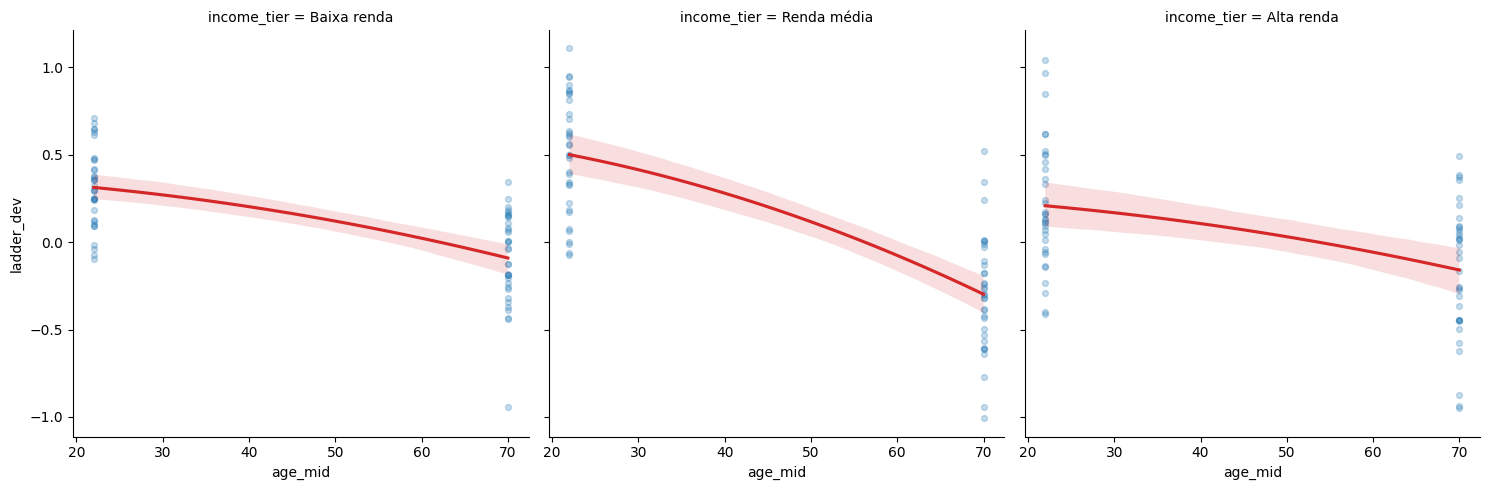

In [ ]:
import seaborn as sns
import pandas as pd

df["ladder_dev"] = df["ladder_mean"] - df.groupby("iso3")["ladder_mean"].transform("mean")

# TODO: crie "income_tier" com pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])
df["income_tier"] = pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])
# TODO: sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2)
sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2, scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})

**Tarefa 3.3. Comparem três modelos em países não vistos.** Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

def cv_scores(features, target="ladder_mean", k=5):
    # Ensure no NaNs in features or target for the current model
    subset_df = df.dropna(subset=features + [target, "iso3"]) # Also ensure iso3 is not NaN for grouping

    # Validação cruzada agrupada por país: um país inteiro fica no treino OU no teste.
    pred = cross_val_predict(LinearRegression(), subset_df[features], subset_df[target],
                             groups=subset_df["iso3"], cv=GroupKFold(n_splits=k))
    return r2_score(subset_df[target], pred), mean_squared_error(subset_df[target], pred) ** 0.5, pred

models = {
    "M1 idade": ["age_mid"],
    "M2 idade + idade^2": ["age_mid", "age_sq"],
    "M3 (M2 + log PIB, log pop, log área)": ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]
}

results = []
for name, features in models.items():
    r2, rmse, _ = cv_scores(features)
    results.append({"Model": name, "Target": "ladder_mean", "R2 Score": r2, "RMSE": rmse})

# Repeat M1 and M2 with target="ladder_dev"
r2_m1_dev, rmse_m1_dev, _ = cv_scores(["age_mid"], target="ladder_dev")
r2_m2_dev, rmse_m2_dev, _ = cv_scores(["age_mid", "age_sq"], target="ladder_dev")

results.append({"Model": "M1 idade", "Target": "ladder_dev", "R2 Score": r2_m1_dev, "RMSE": rmse_m1_dev})
results.append({"Model": "M2 idade + idade^2", "Target": "ladder_dev", "R2 Score": r2_m2_dev, "RMSE": rmse_m2_dev})

results_df = pd.DataFrame(results)
print(results_df)


                                  Model       Target  R2 Score      RMSE
0                              M1 idade  ladder_mean  0.026343  1.232752
1                    M2 idade + idade^2  ladder_mean  0.026343  1.232752
2  M3 (M2 + log PIB, log pop, log área)  ladder_mean  0.584956  0.804859
3                              M1 idade   ladder_dev  0.352815  0.338692
4                    M2 idade + idade^2   ladder_dev  0.352815  0.338692


**Tarefa 3.4. Riqueza e resíduos.** Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (`x="log_gdp_pc"`, colorido por `age_group`), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

Coeficientes do Modelo M3:
age_mid: -0.0000
age_sq: -0.0001
log_gdp_pc: 0.8297
log_pop: -0.0973
log_area: 0.1044
Intercept: -1.8229
Idade do mínimo (curva em U para idade): -0.01 anos


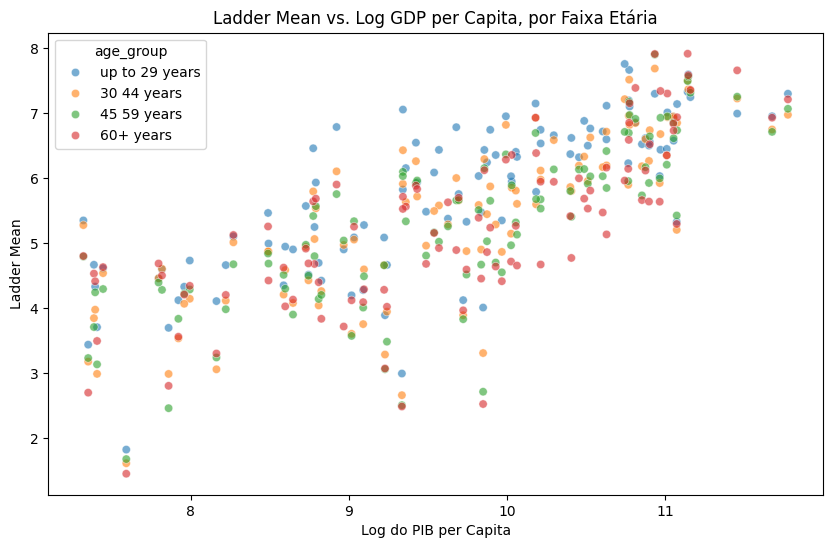

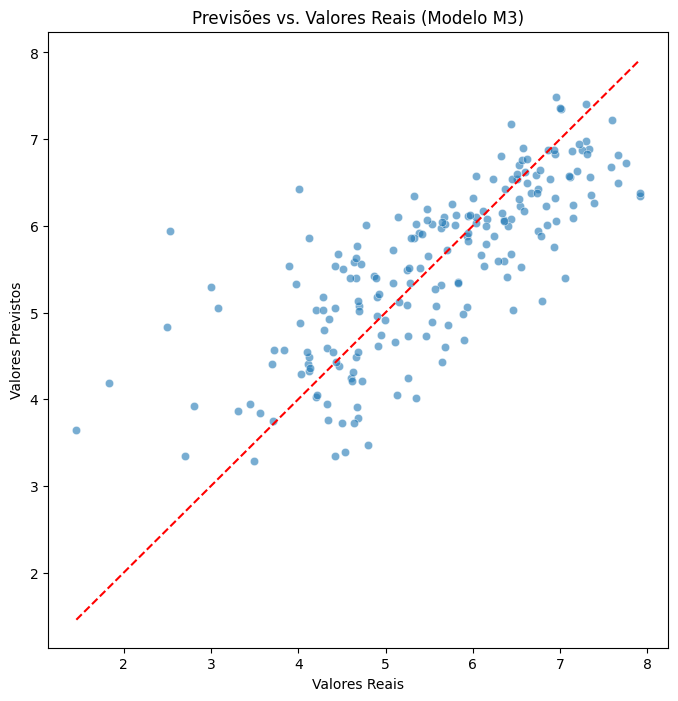

/tmp/ipykernel_1400/2274100889.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df_m3['residuals'] = residuals


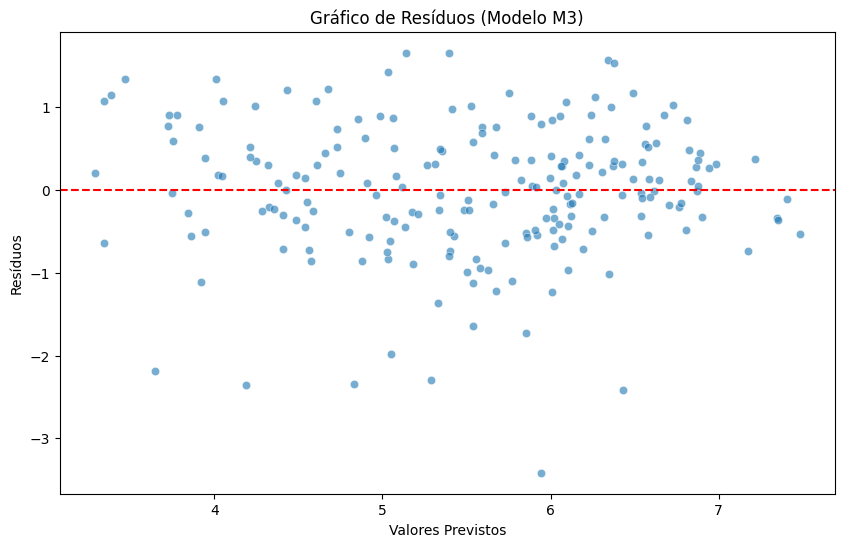


Top 3 países com os maiores resíduos (em valor absoluto):
         country iso3  ladder_mean  residuals
323     Botswana  BWA        2.528  -3.415512
14      Botswana  BWA        4.012  -2.416012
0    Afghanistan  AFG        1.827  -2.360875


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust M3 on all lines
model_m3_features = models["M3 (M2 + log PIB, log pop, log área)"]
lr_m3 = LinearRegression()

# Ensure no NaNs in the features or target for M3 fitting
subset_df_m3 = df.dropna(subset=model_m3_features + ["ladder_mean"])
lr_m3.fit(subset_df_m3[model_m3_features], subset_df_m3["ladder_mean"])

# Print coefficients
print("Coeficientes do Modelo M3:")
for feature, coef in zip(model_m3_features, lr_m3.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {lr_m3.intercept_:.4f}")

# Calculate age of minimum for the quadratic age term (-b1 / (2*b2))
# Assuming 'age_mid' is b1 and 'age_sq' is b2 in the order of features
if 'age_mid' in model_m3_features and 'age_sq' in model_m3_features:
    b1_idx = model_m3_features.index('age_mid')
    b2_idx = model_m3_features.index('age_sq')
    b1 = lr_m3.coef_[b1_idx]
    b2 = lr_m3.coef_[b2_idx]
    if b2 != 0:
        age_of_minimum = -b1 / (2 * b2)
        print(f"Idade do mínimo (curva em U para idade): {age_of_minimum:.2f} anos")
    else:
        print("Coeficiente para age_sq é zero, não há mínimo quadrático.")
else:
    print("age_mid ou age_sq não estão nas features do M3, não é possível calcular o mínimo quadrático.")


# gráfico 1: sns.scatterplot(x="log_gdp_pc", y="ladder_mean", hue="age_group")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="log_gdp_pc", y="ladder_mean", hue="age_group", alpha=0.6)
plt.title("Ladder Mean vs. Log GDP per Capita, por Faixa Etária")
plt.xlabel("Log do PIB per Capita")
plt.ylabel("Ladder Mean")
plt.show()

# gráfico 2: previsto x real (use as previsões de cv_scores)
r2_m3, rmse_m3, pred_m3 = cv_scores(model_m3_features, target="ladder_mean")
plt.figure(figsize=(8, 8))
sns.scatterplot(x=subset_df_m3["ladder_mean"], y=pred_m3, alpha=0.6)
plt.plot([subset_df_m3["ladder_mean"].min(), subset_df_m3["ladder_mean"].max()],
         [subset_df_m3["ladder_mean"].min(), subset_df_m3["ladder_mean"].max()], 'r--')
plt.title("Previsões vs. Valores Reais (Modelo M3)")
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.show()

# gráfico 3: resíduos; liste os 3 países com maiores resíduos
residuals = subset_df_m3["ladder_mean"] - pred_m3
subset_df_m3['residuals'] = residuals

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred_m3, y=residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.title("Gráfico de Resíduos (Modelo M3)")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")
plt.show()

# Liste os 3 países com maiores resíduos
top_3_residuals = subset_df_m3.loc[residuals.abs().nlargest(3).index, ['country', 'iso3', 'ladder_mean', 'residuals']]
print("\nTop 3 países com os maiores resíduos (em valor absoluto):")
print(top_3_residuals)

**O que esperar, e por quê.** As diferenças entre países são grandes perto das diferenças entre idades, então a idade sozinha explica muito pouco da nota bruta, mesmo quando o formato dela é claro dentro dos países. Se o R² de M1 e M2 ficar perto de zero enquanto o gráfico dentro dos países mostra uma curva clara, isso é um **resultado** a explicar no relatório, não um erro.

**Minhas conclusões da Parte 3** (editem esta célula):

...

## 8. Parte 4: regressão logística, feliz ou não por idade e país

A regressão linear prevê uma nota; a regressão logística prevê a **probabilidade** de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar `LogisticRegression` e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

RANDOM_STATE = 42 # Defined here to ensure reproducibility for this cell

THRESHOLD = df["ladder_mean"].median()
df["happy"] = (df["ladder_mean"] > THRESHOLD).astype(int)
print("limiar:", round(THRESHOLD, 2), "| proporção de felizes:", df["happy"].mean().round(2))

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]   # acrescente suas colunas extras aqui
# Dynamically add 'gini_index' if it exists in the DataFrame and is not already in FEATURES
if 'gini_index' in df.columns and "gini_index" not in FEATURES:
    FEATURES.append("gini_index")

def make_classifier():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))

# Prepare the data by dropping rows with NaNs in relevant columns for classification
cols_for_classification = FEATURES + ["happy", "iso3"]
clean_df = df.dropna(subset=cols_for_classification).copy()

X = clean_df[FEATURES]
y = clean_df["happy"]
groups = clean_df["iso3"]

# GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE) com groups=df["iso3"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)

for train_idx, test_idx in gss.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx] # Not strictly needed for evaluation metrics

    # ajuste no treino, use predict_proba no teste e reporte acurácia, AUC e matriz de confusão
    classifier = make_classifier()
    classifier.fit(X_train, y_train)

    y_pred_proba = classifier.predict_proba(X_test)[:, 1] # Probability of being 'happy' (class 1)
    y_pred = (y_pred_proba > 0.5).astype(int) # Classify based on 0.5 threshold

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"\nResultados da Classificação:")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Matriz de Confusão:\n{conf_matrix}")


limiar: 5.57 | proporção de felizes: 0.5

Resultados da Classificação:
Acurácia: 0.8000
AUC: 0.9850
Matriz de Confusão:
[[13  8]
 [ 0 19]]


**Tarefa 4.3. Divisão aleatória versus divisão por país.** Repitam a 4.2 com um `train_test_split` aleatório comum. **Antes de rodar, prevejam** se a pontuação vai subir ou descer e por quê. Depois rodem as duas divisões com 20 sementes aleatórias diferentes e comparem as distribuições do AUC. Façam a mesma comparação com um `RandomForestClassifier` e expliquem o que viram.

**Tarefa 4.4. A função.** Implementem `check_happiness(country, age)` seguindo este contrato:

| Item | Requisito |
| --- | --- |
| Entrada | Nome de um país (qualquer grafia que o `to_iso3` entenda) e uma idade em anos |
| Busca | Encontra `log_gdp_pc`, `log_pop` e `log_area` do país na tabela combinada |
| Saída | Um dicionário com `country`, `age`, `p_happy` (arredondado para 3 casas) e `predicted` (`"happy"` se `p_happy` > 0,5, senão `"not happy"`) |
| Erros | Levanta `ValueError` com mensagem legível se o país for desconhecido ou não tiver dados do Banco Mundial |
| Modelo | Treinado uma vez com todas as linhas, **fora** da função, e passado como argumento padrão |

In [ ]:
from lab_helpers import to_iso3 # Import to_iso3 here
import pandas as pd # Ensure pandas is imported

# Create a cleaned DataFrame for fitting the final classifier
df_for_final_fit = df.dropna(subset=FEATURES + ["happy"]).copy()
final_clf = make_classifier().fit(df_for_final_fit[FEATURES], df_for_final_fit["happy"])

lookup_cols = ["country", "log_gdp_pc", "log_pop", "log_area"]
if "gini_index" in FEATURES:
    lookup_cols.append("gini_index")

# Ensure country_lookup is also built from data without NaNs in lookup columns
country_lookup = (
    df.dropna(subset=lookup_cols)
    .drop_duplicates("iso3")
    .set_index("iso3")[lookup_cols]
)

def check_happiness(country: str, age: float, model=final_clf) -> dict:
    # Retorna P(feliz) e a classe prevista para um país em uma determinada idade.
    # 1) converta o nome para ISO3 com to_iso3(pd.Series([country]))
    iso3_code = to_iso3(country) # Modified to pass string directly, expects string or None back

    # 2) se o ISO3 não estiver em country_lookup, levante ValueError com mensagem clara
    if iso3_code is None or iso3_code not in country_lookup.index:
        raise ValueError(f"Country '{country}' not found or data is missing.")

    country_data = country_lookup.loc[iso3_code]

    # 3) monte uma linha com age_mid=age, age_sq=age**2 e os 3 atributos do país (na ordem de FEATURES)
    input_features = {
        "age_mid": age,
        "age_sq": age**2,
        "log_gdp_pc": country_data["log_gdp_pc"],
        "log_pop": country_data["log_pop"],
        "log_area": country_data["log_area"],
    }
    if "gini_index" in FEATURES: # Add gini_index if it's part of the features
        # Check if gini_index is available for the country before adding
        if "gini_index" in country_data and pd.notna(country_data["gini_index"]):
            input_features["gini_index"] = country_data["gini_index"]
        else:
            # If gini_index is a required feature but missing, raise an error or handle it
            raise ValueError(f"GINI index data missing for country '{country}'.")

    # Create a DataFrame for prediction, ensuring column order matches FEATURES
    input_df = pd.DataFrame([input_features], columns=FEATURES)

    # 4) calcule p com model.predict_proba e devolva o dicionário do contrato
    p_happy = model.predict_proba(input_df)[:, 1][0] # Probability of being 'happy' (class 1)
    predicted_class = "happy" if p_happy > 0.5 else "not happy"

    return {
        "country": country_data["country"],
        "age": age,
        "p_happy": round(p_happy, 3),
        "predicted": predicted_class
    }

**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.

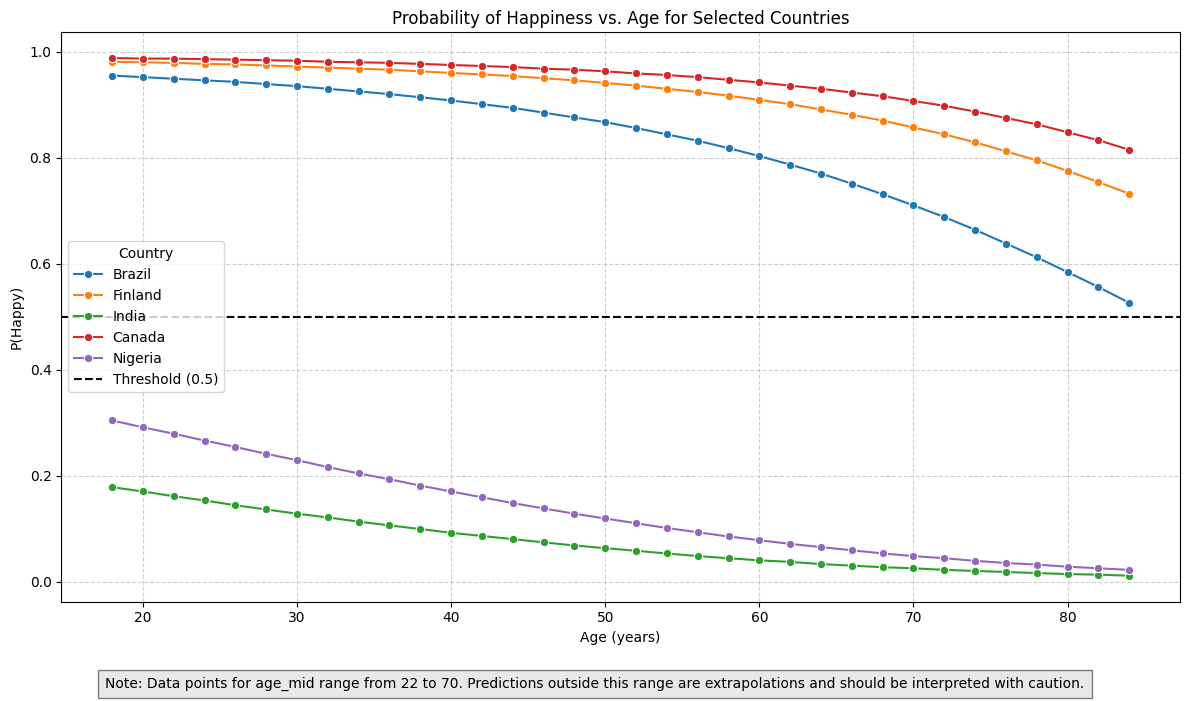

In [ ]:
chosen = ["Brazil", "Finland", "India", "Canada", "Nigeria"]   # Choosing 5 countries from different income tiers with complete data
ages = np.arange(18, 86, 2)

# mount "curves" (DataFrame with columns age, country, p_happy) calling check_happiness
curves_data = []
for country_name in chosen:
    for age_val in ages:
        try:
            result = check_happiness(country_name, age_val)
            curves_data.append({
                "country": result["country"],
                "age": result["age"],
                "p_happy": result["p_happy"]
            })
        except ValueError as e:
            print(f"Skipping {country_name} for age {age_val} due to error: {e}")
            continue

curves = pd.DataFrame(curves_data)

# sns.lineplot(data=curves, x="age", y="p_happy", hue="country"); plt.axhline(0.5, ls="--", color="k")
plt.figure(figsize=(12, 7))
sns.lineplot(data=curves, x="age", y="p_happy", hue="country", marker='o')
plt.axhline(0.5, ls="--", color="k", label="Threshold (0.5)")
plt.title("Probability of Happiness vs. Age for Selected Countries")
plt.xlabel("Age (years)")
plt.ylabel("P(Happy)")
plt.legend(title="Country")
plt.grid(True, linestyle='--', alpha=0.6)
plt.figtext(0.5, 0.01, "Note: Data points for age_mid range from 22 to 70. Predictions outside this range are extrapolations and should be interpreted with caution.", ha="center", fontsize=10, bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Um ponto estrutural para discutir. As quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área, então o modelo só consegue separá-las pela idade. Expliquem o que isso implica sobre o quanto o modelo realmente "sabe" sobre cada país.

**Minhas conclusões da Parte 4** (editem esta célula):

...

## 9. Discussão (cerca de meia página, com as palavras de vocês)

Respondam nesta célula. Usem as frases do Passo 0 e os resultados das Partes 3 e 4.

1. O perfil de idade **dentro dos países** mostra uma curva em U? Onde fica o mínimo? Como isso se compara ao artigo do WEF e ao resumo do WHR 2024?
2. Comparem o tamanho do efeito da idade com o do efeito da riqueza. Qual pesa mais para prever a nota de um país, e qual pesa mais para prever diferenças **dentro** de um país?
3. As linhas de vocês são médias de grupos por país, não indivíduos. Por que um padrão nas médias pode falhar em descrever qualquer pessoa em particular (a **falácia ecológica**)?
4. A idade aqui é o ponto médio de quatro faixas. Que informação isso descartou, e como uma curva em U poderia parecer diferente com idades em anos simples?
5. Uma fotografia de muitos países mistura **idade** com **coorte de nascimento**. O WHR 2024 encontra avaliações de vida menores em quem nasceu depois de 1980. Por que não dá para separar um efeito de idade de um efeito de coorte com um único corte transversal?
6. O que a escolha do limiar de "feliz" fez com os resultados de classificação, e vocês confiariam em um ponto de corte de probabilidade 0,5 para uma política pública?

**Respostas da dupla:**

1. A visão clássica aponta para uma curva em U, onde a felicidade atinge seu ponto mínimo por volta dos 40 ao início dos 50 anos, padrão corroborado pelo WEF em países de renda alta. Contudo, o WHR 2024 demonstra que esse perfil varia regionalmente: enquanto os jovens na América do Norte registraram quedas no bem-estar e estão menos felizes que os mais velhos, na Europa Central e Oriental a felicidade subiu em todas as faixas etárias, quebrando a universalidade da curva em U.


2. Os fatores relacionados à riqueza, como o PIB per capita, possuem um peso substancialmente maior na previsão das notas gerais dos países, visto que a variação da felicidade é muito mais expressiva entre diferentes nações do que entre faixas etárias. Para explicar as variações etárias dentro de um mesmo país, o efeito da idade só ganha relevância prática após o modelo controlar e fixar suas características estruturais.


3. O uso de dados estruturados com base em médias da escada de Cantril agregadas por faixas etárias amplas cria um retrato estritamente coletivo da população. Analisar dados agrupados apaga as variações, exceções e o contexto pessoal dos indivíduos, incorrendo na falácia ecológica ao tentar usar o padrão das médias para descrever a realidade de qualquer pessoa em particular.


4. Ao fixar pontos médios em 22, 37, 52 e 70 anos para representar faixas temporais amplas, o cálculo descartou os impactos anuais contínuos e as variações abruptas entre anos consecutivos. Se fossem utilizados anos simples, a curva não apresentaria arcos suaves, revelando mínimos mais pontiagudos ou desvios em momentos de grande transição de vida — como o ano exato da aposentadoria — que acabam sendo ocultados por esse resumo.


5. Embora o WHR 2024 identifique avaliações de vida menores em nascidos após 1980, a base de dados utiliza médias relativas ao período estático de 2021-2023, onde jovens e idosos são avaliados simultaneamente sob as mesmas condições globais. Por se tratar de um único corte transversal, a matemática é incapaz de isolar se a insatisfação decorre dos desafios inerentes à faixa etária atual (efeito de idade) ou do contexto histórico e tecnológico vivido por essa geração específica (efeito de coorte).


6. A conversão das avaliações em rótulos binários simplifica a análise para uma regressão logística focada apenas em prever o grupo "acima" ou "abaixo" do limiar, eliminando o conceito de intensidade e a variação entre os níveis de satisfação. Um limiar genérico de probabilidade 0,5 não é confiável para a formulação de políticas públicas por ignorar divergências sociodemográficas e geográficas cruciais para o direcionamento de recursos estatais a populações vulneráveis.

## 10. Entrega: GitHub (portfólio) e MS Teams

Este é um **projeto em dupla**. O prazo é o **final do dia da aula**, e o projeto **pode ser feito durante a aula de laboratório**. A entrega tem duas partes: publicar no GitHub e enviar o link no MS Teams.


### 10.1 Publicar no GitHub (item do portfólio)

1. Criem um repositório **público** no GitHub, por exemplo `felicidade-idade-pais`. Ele será um item do portfólio de vocês, então cuidem da apresentação.
2. Coloquem no repositório: este notebook (executado, **com as saídas salvas**), o `lab_helpers.py`, um `requirements.txt` e um `README.md`.
3. O `README.md` deve ter: título e uma frase de contexto; os nomes da dupla; como executar (versão do Python e `pip install -r requirements.txt`); duas ou três figuras principais e a conclusão em poucas linhas; limitações; e as **fontes citadas** (World Happiness Report, Our World in Data e Banco Mundial, com a data do download).
4. Os **dois integrantes** devem aparecer nos commits. Se um só fizer os commits, adicionem o outro como colaborador (*Settings → Collaborators*) e alternem quem faz o push.
5. Antes de publicar, rodem **Kernel → Restart & Run All** e salvem o notebook. O GitHub mostra as saídas gravadas no arquivo.


Estrutura sugerida:

```text
felicidade-idade-pais/
├── README.md
├── requirements.txt
├── lab_helpers.py
├── lab_felicidade_idade_pais.ipynb
└── figures/            (opcional: PNGs exportados)
```





Comandos básicos:

```bash
git init
git add .
git commit -m "Lab: felicidade por idade e país"
git branch -M main
git remote add origin https://github.com/<usuario>/<repositorio>.git
git push -u origin main
```








### 10.2 Enviar no MS Teams

Copiem o **link do repositório** (por exemplo `https://github.com/<usuario>/<repositorio>`) e enviem na **atividade correspondente do MS Teams**, antes do fim do prazo. Só um integrante precisa enviar, mas escrevam no texto da entrega os nomes dos dois. Confiram em uma janela anônima do navegador se o link abre sem login.

Conteúdo mínimo do `requirements.txt`:

```text
pandas
numpy
scikit-learn
seaborn
matplotlib
requests
openpyxl
country_converter
```



### 10.3 Avaliação

| Processo | Componente | Pontos |
| --- | --- | --- |
| ASK | Notas de leitura (uma frase por fonte) e parágrafo de contexto | 1 |
| GET, EXPLORE | Carga, enriquecimento e auditoria do *join* (países descartados listados e explicados) | 2 |
| MODEL | Regressão linear: figuras 3.1 a 3.4, tabela com três modelos, validação cruzada por país | 2 |
| MODEL | Regressão logística: rótulo, avaliação agrupada, `check_happiness`, curvas de probabilidade | 2 |
| COMMUNICATE | Discussão dos limites e interpretação honesta | 1,5 |
| COMMUNICATE | Publicação no GitHub e reprodutibilidade: README, `requirements.txt`, commits dos dois, notebook roda do início ao fim, sementes fixas, link enviado no Teams | 1,5 |
| **Total** | **10** |

> Esta atividade de LAB vai compor a média (QUIZ, LAB, LAB, LAB..., PROJETO)




### 10.4 Desafios extras (do mais simples ao mais difícil)

- Acrescentem uma variável de **região** e uma interação `idade × região` para testar a descoberta do WHR de que a América do Norte e a Europa Central e Oriental fogem do padrão em U.
- Comparem 2006-2010 com 2021-2023, se o professor fornecer as duas janelas, e testem se a felicidade dos jovens caiu.
- Regularizem com `Ridge` ou `LogisticRegression(C=...)` e escolham a força por validação cruzada agrupada.
- Desenhem uma **curva de calibração** do classificador e discutam se as probabilidades podem ser lidas como probabilidades.
- Troquem o limiar da mediana por um alvo ordinal e ajustem um modelo multiclasse.

### 10.5 Citações

Citem o **World Happiness Report**, o **Our World in Data** e o **Banco Mundial** no notebook e no README. Informem a **data exata do download** e os **anos** que os dados cobrem, porque essas fontes revisam suas séries. Façam o mesmo para cada conjunto de dados extra que acrescentarem: fonte, data do download, anos e chave de junção.

**Fontes das leituras:**

- [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx)
- [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/)
- [WHR 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/)
- [WHR 2024: Happiness of the younger, the older, and those in between](https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/)
- [Our World in Data: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table)
- [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)

## LIB

Podemos criar nossa própria LIB (arquivo helper), para organizar melhor o código e facilitar reutilização (opcional). Criar um arquivo texto .py e implementar suas funções neste arquivo.

Importar o arquivo e usar as funções, lembre de subir o arquivo  `.py` no GitHub também...

A sua LIB deve ficar no mesmo diretório do `.ipynb`

Exemplo: arquivo `mylib.py`

```python
def soma(a, b):
  "Soma dois valores"
  return a + b
```

In [ ]:
import mylib

mylib.soma(1000,200)

In [ ]:
mylib.soma(.5,200)

In [ ]:
mylib.soma("Vai ", "Corinthians!!")

In [ ]:
help(mylib.soma)

## Modelos de Regressão

Principais tipos de modelos de regressão utilizados em Inteligência Artificial e Aprendizado de Máquina:

### Modelos de Regressão Clássicos e Estatísticos

* Regressão Linear: Modela uma relação linear entre variáveis. É usada para prever um valor numérico contínuo com base em uma reta que minimiza a distância entre os pontos dos dados.
* Regressão Logística: Classifica dados em categorias binárias (como sim/não). Apesar do nome "regressão", ela calcula a probabilidade de um evento acontecer usando uma curva sigmoide.
* Regressão Polinomial (e Quadrática): Estende a regressão linear para modelar relações curvas. A regressão quadrática adiciona variáveis ao quadrado ($x^2$) para desenhar uma parábola que se ajusta a padrões não lineares.
* Regressão Exponencial: Modela dados que crescem ou decrescem de forma acelerada. É ideal quando a taxa de variação da variável alvo é proporcional ao seu valor atual (como crescimento populacional).

### Modelos Avançados e Baseados em IA

* Árvores de Decisão para Regressão: Dividem os dados repetidamente em subgrupos com base em perguntas lógicas. A previsão final é a média dos valores do grupo em que o dado terminou.
* Random Forest (e Modelos de Ensemble): Combina dezenas de árvores de decisão independentes. A previsão final é a média dos resultados de todas as árvores, reduzindo erros e aumentando a precisão.
* Gradient Boosting (como XGBoost e LightGBM): Constrói árvores de decisão sequencialmente. Cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores.
* Máquinas de Vetores de Suporte (SVR): Encontra uma linha (ou hiperplano) de melhor ajuste dentro de uma margem de tolerância definida. Busca prever valores contínuos maximizando a distância entre os pontos mais distantes.
* Redes Neurais Artificiais (Deep Learning): Utiliza camadas de neurônios matemáticos interconectados. É capaz de aprender relações extremamente complexas e padrões altamente não lineares em grandes volumes de dados.

### Para aprender mais

Introduction to Machine Learning: Regression by Etienne Bernard<br>
https://www.wolfram.com/language/introduction-machine-learning/regression/


## Documentação

Documentação online atualizada:

- https://scikit-learn.org/stable/user_guide.html
- https://pandas.pydata.org/getting_started.html
- https://numpy.org/learn/
- https://requests.readthedocs.io/en/latest/
- https://pythonfluente.com/2/
- https://git-scm.com/docs

## Bibliografia

- Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/
- Artificial Intelligence: A Modern Approach, 4th US ed: https://aima.cs.berkeley.edu/
- An Introduction to Statistical Learning, Python: https://www.statlearning.com/
- Introduction to Machine Learning (Etienne Bernard): https://www.wolfram.com/language/introduction-machine-learning/

## Infográficos

![](https://helloskillio.com/wp-content/uploads/2025/10/What-is-Pair-Programming-A-Complete-Guide-for-Beginners.webp)

![](https://statisticalanalysishelp.com/wp-content/uploads/2026/05/Untitled-design-5-1024x683.jpg)

https://statisticalanalysishelp.com/difference-between-logistic-and-linear-regression/

![](https://www.otechtalks.tv/wp-content/uploads/2020/04/data-science-process.jpg)